# ***STRESS LYSIS***

***ABOUT THE DATA & THE NOTEBOOK***

**Based on the human’s physical activity, the stress levels of the human being are detected and analyzed. A dataset of 2001 samples is provided for human body humidity, body temperature and the number of steps taken by the user. Three different classifications of stress are analyzed such as low stress, normal stress, and high stress.** 

**In this notebook, I've analyzed the features of the dataset, trained the model and finally deployed it too.**

**HIT THE UPVOTE 🔼**

In [ ]:
# File - Stress_Lysis.ipynb

# ***IMPORTS***

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input-data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# ***DATA COLLECTION***

* ***Reading the Data Files***

In [ ]:
data=pd.read_csv('/kaggle/input/input-data/Stress-Lysis.csv')
data.head()  # displays the first five rows of the dataframe

# ***ANALYZING THE DATA***

In [ ]:
data.shape  # returns a tuple of array dimension that specifies the number of rows and columns

In [ ]:
data.info()  # prints the information about the dataframe

In [ ]:
data.describe()  # returns the statistical summary of the data

# ***DATA CLEANING***

***STEPS:***

***1. Analyze the numerical and categorical features, and convert categorical feature into numerical.***

Stress Level
0 - Low stress
1 - Normal stress
2 - High Stress

In [ ]:
data['Stress_Level'].unique()

***2. Check for missing values and handle them.***

In [ ]:
data.isnull().sum()

***3.Check for duplicate values***

In [ ]:
data.duplicated().sum()

# ***EDA - EXPLORATORY DATA ANALYSIS***

***1.Univariate Non-Graphical***

***Check for outliers. If present try to handle them.***

In [ ]:
data.skew()

In [ ]:
plt.figure(figsize=(4,4))
plt.boxplot(data)
plt.show()

All 4 columns consists skewness.

***Skewness Reduction***

In [ ]:
# Logarithmic Transformation
hum_log = np.log(data['Humidity'])
h = round(hum_log.skew(),10)
print(h)

In [ ]:
# SquareRoot Transformation
temp_sqrt = np.sqrt(data['Temperature'])
temp_sqrt.skew()
t = round(temp_sqrt.skew(),10)
print(t)

In [ ]:
quantile1=data["Step_count"].quantile(0.25)
quantile2=data["Step_count"].quantile(0.75)

In [ ]:
quantile1

In [ ]:
quantile2

In [ ]:
data["Step_count"]=np.where(data["Step_count"]<quantile1,quantile1,data["Step_count"])
data["Step_count"]=np.where(data["Step_count"]>quantile2,quantile2,data["Step_count"])

In [ ]:
s = round(data['Step_count'].skew(),10)
print(s)

In [ ]:
# SquareRoot Transformation
stress_sqrt = np.sqrt(data['Stress_Level'])
sl = round(stress_sqrt.skew(),10)
print(sl)

***2.Univariate Graphical***

In [ ]:
column=['Step_count','Humidity']
for category in column:
    plt.figure(figsize=(3,3))
    plt.hist(data[category])
    plt.title(category)
    plt.show()

In [ ]:
# histplot (categorical) 
plt.figure(figsize=(3,3))
sns.set(font_scale=1)
sns.histplot(data=data, x='Stress_Level')

In [ ]:
plt.figure(figsize=(3,3))
sns.boxplot(data['Temperature'])

***3.Multivariate Non-Graphical***

***Correlation***

In [ ]:
correlation = data.corr()
correlation

In [ ]:
plt.figure(figsize=(3,3))
sns.heatmap(correlation,annot=True,cmap='crest',linewidths=0.2)
plt.show()

***4.Multivariate Graphical***

In [ ]:
plt.figure(figsize=(3,3))
sns.scatterplot(x='Humidity',y='Temperature',hue='Stress_Level',data=data)
plt.show()

# ***MODELLING***

In [ ]:
from sklearn.model_selection import train_test_split
X=data.drop(['Stress_Level'],axis=1)
y=data['Stress_Level']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

***LOGISTIC REGRESSION***

In [ ]:
from sklearn.linear_model import LogisticRegression
regressor = LogisticRegression(C=1.0,random_state=2)
regressor.fit(X_train,y_train)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
prediction = regressor.predict(X_test)
confusionmatrix = confusion_matrix(y_test,prediction)
print(confusionmatrix)

In [ ]:
print(accuracy_score(y_test,prediction))

***RANDOM FOREST CLASSIFICATION***

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,max_depth=3,random_state=0)
model.fit(X,y)
prediction = model.predict(X_test)
confusionmatrix = confusion_matrix(y_test,prediction)
print(confusionmatrix)

In [ ]:
print(accuracy_score(y_test,prediction))

***SUPPORT VECTOR MACHINE***

In [ ]:
from sklearn.preprocessing import StandardScalar
standardscalar = StandardScalar()
X_train = standardscalar.fit_transform(X_train)
X_test = standardscalar.transform(X_train)

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=0)  
classifier.fit(X_train, y_train)  

In [ ]:
y_predict= classifier.predict(X_test)
score=accuracy_score(y_test,y_predict)
print(score)

# ***DEPLOYMENT***

***SAVING THE TRAINED MODEL***

In [ ]:
import pickle

In [ ]:
filename = 'stress_trained.sav'
pickle.dump(classifier,open(filename,'wb'))

***LOADING THE TRAINED MODEL***

In [ ]:
loaded_model = pickle.load(open('stress_trained.sav','rb'))
# Download the stress_trained.sav model 

In [ ]:
# Evaluating

input_data = (11.05,80.05,14) #300
#changing the input data into numpy array
id_np_array = np.asarray(input_data)
id_reshaped = id_np_array.reshape(1,-1)

prediction = classifier.predict(id_reshaped)
print(prediction)

if(prediction[0]==0):
    print("Stress Level: LOW")
elif(prediction[0]==1):
    print("Stress Level: MEDIUM")
else:
    print("Stress Level: HIGH")
    
input_data = (21.38,90.38,128) #100
#changing the input data into numpy array
id_np_array = np.asarray(input_data)
id_reshaped = id_np_array.reshape(1,-1)

prediction = classifier.predict(id_reshaped)
print(prediction)

if(prediction[0]==0):
    print("Stress Level: LOW")
elif(prediction[0]==1):
    print("Stress Level: MEDIUM")
else:
    print("Stress Level: HIGH")
    
input_data = (25.41,94.41,167) #200
#changing the input data into numpy array
id_np_array = np.asarray(input_data)
id_reshaped = id_np_array.reshape(1,-1)

prediction = classifier.predict(id_reshaped)
print(prediction)

if(prediction[0]==0):
    print("Stress Level: LOW")
elif(prediction[0]==1):
    print("Stress Level: MEDIUM")
else:
    print("Stress Level: HIGH")

In [ ]:
# File - Predictive System.py

# Imports
import numpy as np
import pickle

# Loading the trained model
loaded_model = pickle.load(open('stress_trained.sav','rb'))
# stress_trained.sav - replace the path of the file along with the file name
# Example: loaded_model = pickle.load(open('C:/Users/jeyasri/Downloads/PROJECT/stress_trained.sav','rb'))



input_data = (25.41,94.41,167) #200
#changing the input data into numpy array
id_np_array = np.asarray(input_data)
id_reshaped = id_np_array.reshape(1,-1)

prediction = loaded_model.predict(id_reshaped)
print(prediction)

if(prediction[0]==0):
    print("Stress Level: LOW")
elif(prediction[0]==1):
    print("Stress Level: MEDIUM")
else:
    print("Stress Level: HIGH")

In [ ]:
# Trying to install streamlit
!pip install -q streamlit

In [ ]:
import numpy as np
import pickle
import streamlit as st  

# Loading the trained model
loaded_model = pickle.load(open('stress_trained.sav','rb'))
# Replace path over stress_trained.sav

def stresslevel_prediction(input_data):
    
    #changing the input data into numpy array
    id_np_array = np.asarray(input_data)
    id_reshaped = id_np_array.reshape(1,-1)

    prediction = loaded_model.predict(id_reshaped)
    print(prediction)

    if(prediction[0]==0):
        return "Stress Level: LOW"
    elif(prediction[0]==1):
        return "Stress Level: MEDIUM"
    else:
        return "Stress Level: HIGH"
    
def main():
    
    st.title('STRESS LEVEL PREDICTION WEB APP')
    
    Humidity = st.text_input('Humidity Value')
    Temperature = st.text_input('Body Temperature')
    Step_count = st.text_input('Number of Steps')
    
    # Prediction code
    diagnosis = ''
    
    if st.button('PREDICT'):
        diagnosis = stresslevel_prediction([Humidity, Temperature, Step_count])
        
    st.success(diagnosis)
    
if __name__=='__main__':
    main()

**Go to command prompt open the terminal and execute the command.**

streamlit run "path of the file.py"

Example: streamlit run "C:\Users\jeyasri\Downloads\PROJECT\Stress Level Prediction Web App.py"

**Your final result will be like this...**

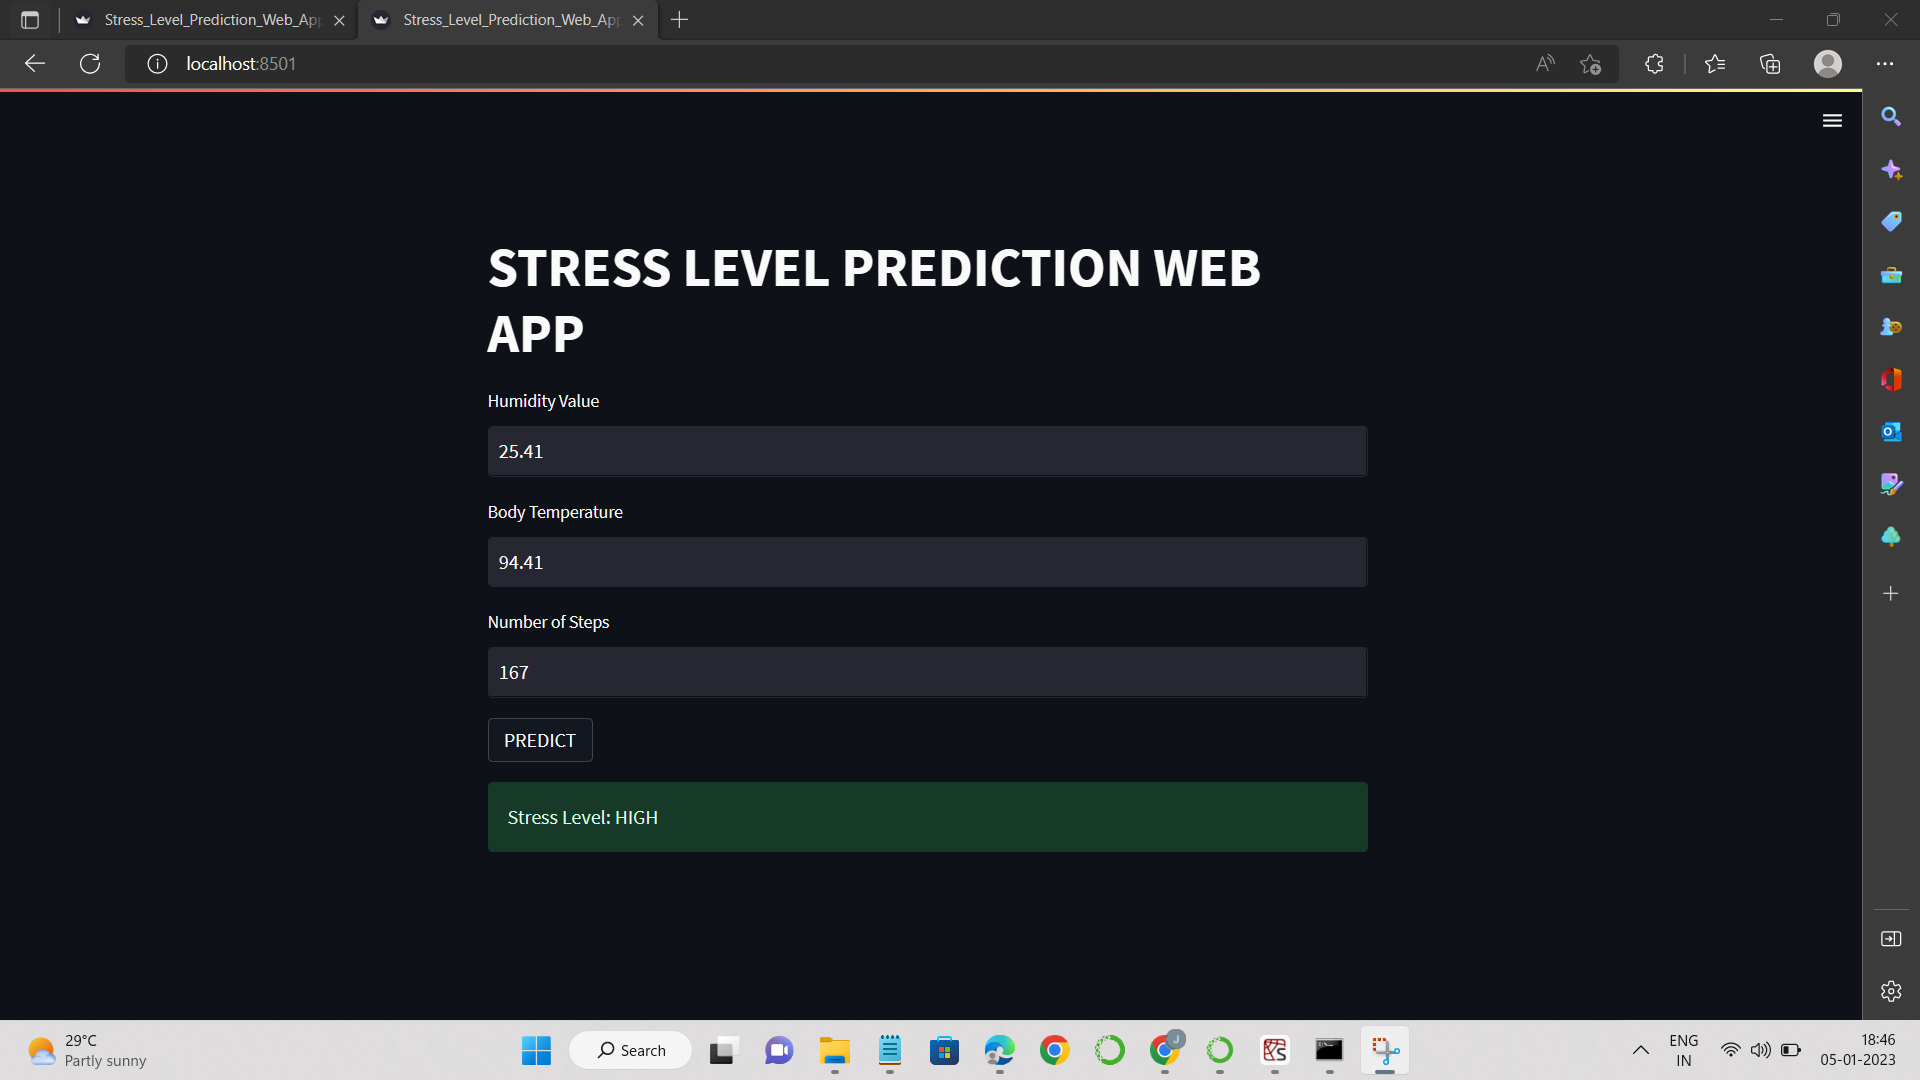